 **Problema 3: Integración mediante PINNs**

Elija un flujo del Problema 1 o del Problema 2. Compararemos las trayectorias obtenidas (sea analítica o numéricamente) con lo obtenido mediante el uso de Redes Neuronales Informadas por la Física (PINNs, vease apunte).
Limitese a una única trayectoria, dada por un único punto inicial $(x_0, y_0)$ y un dado conjunto de parámetros adimensionales (si elige un flujo del Problema 1, antes adimensionalícelo).
Elija un tiempo de integración $T$ tal que la dinámica es rica (puede ser el mismo que usó para integrar numéricamente).
En la celda a continuación le proporcionamos la estructura general de la PINN.

(i) Provea a la red con $10$ puntos de entrenamiento de datos, $20$ puntos de entrenamiento de física y $\lambda = 10^{-4}$, ambos equiespaciados en $[0, T]$ (asegúrese de incluir tanto $0$ cómo $T$), y entrénela durante $20000$ épocas. Grafique tanto el error de los datos cómo el de la física en función de la época para determinar. Interprete. ¿Cuantas épocas considera suficientes?

(ii) Utilice la red entrenada (con $20000$ épocas) para calcular la trayectoria más allá de $T$ y calcule el error $\epsilon(t) = |\mathbf{X}_\mathrm{PINN}(t) - \mathbf{X}(t)|$. Grafiquelo e interprete. ¿Hasta que valor de $t$ considera adecuada la red? ¿Puede identificar los tiempos donde $\mathbf{X}(t)$ corresponde a un punto de entrenamiento y/o de física? Repita esto para un entrenamiento con puntos de entrenamiento de física uniformemente distribuidos en $[0, 2T]$, **sin cambiar la cantidad**. ¿Mejora la aproximación? Interprete.

(iii) Manteniendo los $20$ puntos de entrenamiento de física, varíe la cantidad de puntos de entrenamiento de datos $N_d$ entre $2$ y $20$ y grafique el error medio $\epsilon_M = \sum_n \epsilon(t_n)$ para cada $N_d$. Interprete la ganancia de precisión teniendo en cuenta el tiempo de entrenamiento necesario. ¿Cambia la cantidad de épocas óptima para cada $N_d$?

(iv) Repita el inciso anterior pero manteniendo $N_d = 10$ puntos de entrenamiento de datos y varíe la cantidad de puntos de entrenamiento de física $N_f$ entre $5$ y $50$.

(v) Fijando $N_d=10$ y $N_f=20$, varie $\lambda$ logarítmicamente entre $10^{-6}$ y $10^{-1}$ y compare ambas funciones de pérdida y $\epsilon_M$ para cada caso.

(vi) (Opcional) Fijando $N_d$, $N_f$ y $\lambda$ a gusto, pruebe distintas arquitecturas para la red y compare sus desempeños. ¿Considera alguna óptima? _Ayuda: Por cuestiones de desempeño, evite redes con más de 3 capas ocultas._


=== Experimento 1: Puntos de física en [0, T] ===
Epoch     0 | Total: 5.36e+01 | Data: 5.81e+00 | Physics: 4.78e+01
Epoch  2000 | Total: 1.99e-01 | Data: 3.80e-02 | Physics: 1.61e-01
Epoch  4000 | Total: 7.67e-03 | Data: 4.47e-04 | Physics: 7.22e-03
Epoch  6000 | Total: 5.26e-04 | Data: 7.34e-06 | Physics: 5.19e-04
Epoch  8000 | Total: 2.17e-04 | Data: 3.08e-06 | Physics: 2.14e-04
Epoch 10000 | Total: 9.31e-05 | Data: 1.35e-06 | Physics: 9.17e-05
Epoch 12000 | Total: 1.81e-05 | Data: 2.48e-07 | Physics: 1.78e-05
Epoch 14000 | Total: 1.68e-06 | Data: 1.60e-08 | Physics: 1.66e-06
Epoch 16000 | Total: 6.54e-07 | Data: 2.21e-08 | Physics: 6.32e-07
Epoch 18000 | Total: 4.10e-07 | Data: 2.50e-08 | Physics: 3.85e-07
Entrenamiento completado.



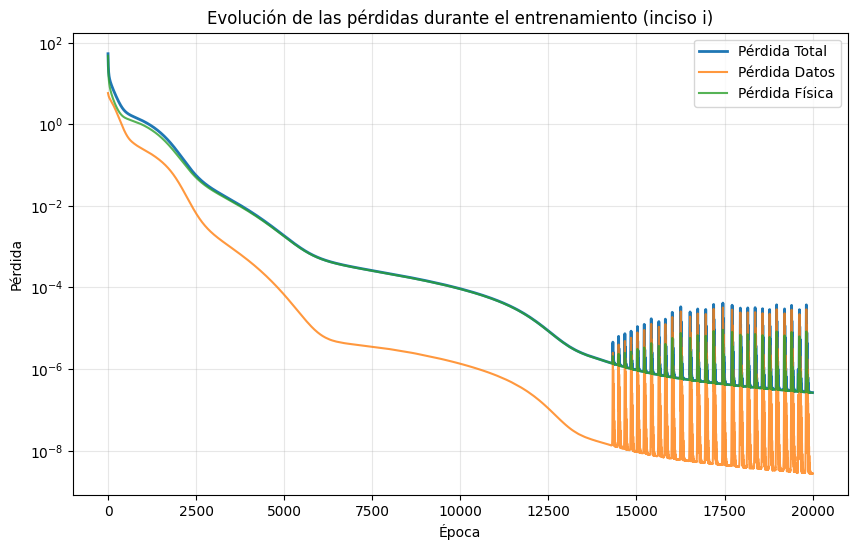

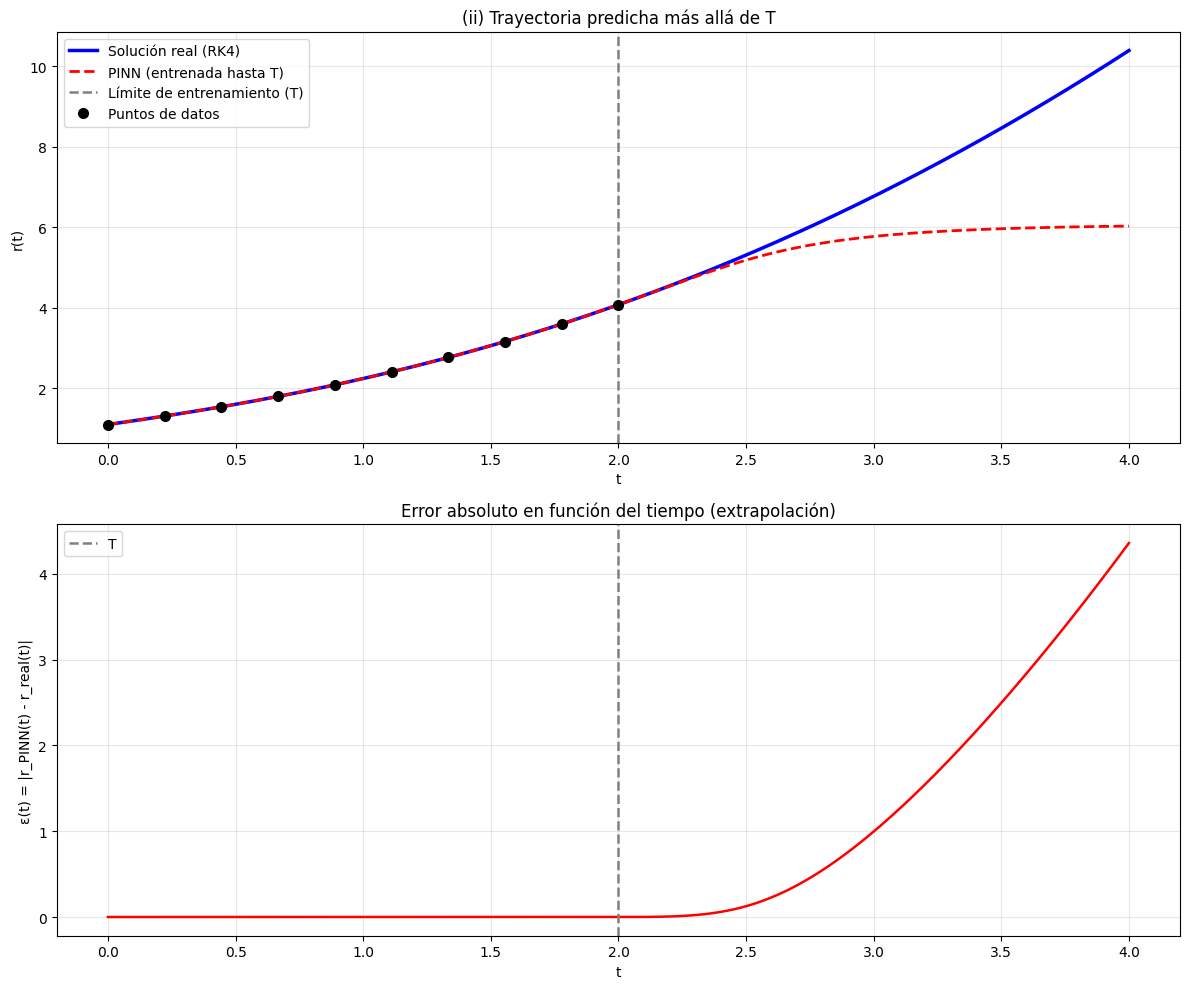

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import torch

# ====================== FUNCIÓN DE LA EDO ======================
def f(t, r):
    return 1.0 / r + t

def rk4_scalar(f, t0, r0, T, N):
    dt = T / N
    t = np.zeros(N+1)
    r = np.zeros(N+1)
    t[0] = t0
    r[0] = r0
    for i in range(N):
        ti = t[i]
        ri = r[i]
        k1 = f(ti, ri)
        k2 = f(ti + dt/2, ri + dt*k1/2)
        k3 = f(ti + dt/2, ri + dt*k2/2)
        k4 = f(ti + dt, ri + dt*k3)
        r[i+1] = ri + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
        t[i+1] = ti + dt
    return t, r


# ====================== CLASE PINN ======================
class PINN(torch.nn.Module):
    def __init__(self, hidden_sizes=[32, 32, 32]):
        super().__init__()
        layers = [1] + hidden_sizes + [1]
        self.layers = torch.nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(torch.nn.Linear(layers[i], layers[i+1]))
        
        self.loss_history = []
        self.loss_data_history = []
        self.loss_physics_history = []

    def forward(self, t):
        x = t
        for layer in self.layers[:-1]:
            x = torch.tanh(layer(x))
        return self.layers[-1](x)

    def data_loss(self, t_data, r_data):
        return torch.mean((self.forward(t_data) - r_data)**2)

    def physics_loss(self, t_physics, f_func):
        t_physics = t_physics.requires_grad_(True)
        r = self.forward(t_physics)
        dr_dt = torch.autograd.grad(r, t_physics, torch.ones_like(r), create_graph=True)[0]
        residual = dr_dt - f_func(t_physics, r)
        return torch.mean(residual ** 2)

    def total_loss(self, t_data, r_data, t_physics, f_func, lambda_phys=1e-4):
        ld = self.data_loss(t_data, r_data)
        lp = self.physics_loss(t_physics, f_func)
        return ld + lambda_phys * lp, ld, lp

    def train_pinn(self, t_data, r_data, t_physics, f_func,
                   lambda_phys=1e-4, epochs=20000, lr=1e-4, print_every=2000):
        optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        for epoch in range(epochs):
            optimizer.zero_grad()
            loss_total, ld, lp = self.total_loss(t_data, r_data, t_physics, f_func, lambda_phys)
            loss_total.backward()
            optimizer.step()

            self.loss_history.append(loss_total.item())
            self.loss_data_history.append(ld.item())
            self.loss_physics_history.append(lp.item())

            if epoch % print_every == 0:
                print(f"Epoch {epoch:5d} | Total: {loss_total.item():.2e} | "
                      f"Data: {ld.item():.2e} | Physics: {lp.item():.2e}")
        print("Entrenamiento completado.\n")
        return self

    def plot_loss(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history, label='Pérdida Total', linewidth=2)
        plt.plot(self.loss_data_history, label='Pérdida Datos', alpha=0.8)
        plt.plot(self.loss_physics_history, label='Pérdida Física', alpha=0.8)
        plt.yscale('log')
        plt.xlabel('Época')
        plt.ylabel('Pérdida')
        plt.title('Evolución de las pérdidas durante el entrenamiento (inciso i)')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

# ====================== CONFIGURACIÓN ======================
T = 2.0
r0 = 1.1
Nd = 10
Nf = 20
lambda_phys = 1
epochs = 20000

# Solución real hasta T
t_real, r_real = rk4_scalar(f, 0.0, r0, T, 2000)

# Puntos de datos
t_data = torch.linspace(0, T, Nd).view(-1, 1)
r_data = torch.tensor(np.interp(t_data.squeeze().numpy(), t_real, r_real), 
                      dtype=torch.float32).view(-1, 1)

# ====================== Ejercicio i) ======================
print("=== Experimento 1: Puntos de física en [0, T] ===")
t_physics1 = torch.linspace(0, T, Nf).view(-1, 1)

pinn1 = PINN([64, 64, 64])
pinn1.train_pinn(t_data, r_data, t_physics1, f, lambda_phys=lambda_phys, epochs=epochs)
pinn1.plot_loss()


# ====================== EXTRAPOLACIÓN MÁS ALLÁ DE T ======================
T_ext = 2.0 * T
t_test_ext = torch.linspace(0, T_ext, 800).view(-1, 1)

# Solución real extendida
t_real_ext, r_real_ext = rk4_scalar(f, 0.0, r0, T_ext, 4000)

with torch.no_grad():
    r_pred1 = pinn1(t_test_ext).squeeze().numpy()

# Error absoluto
error1 = np.abs(r_pred1 - np.interp(t_test_ext.squeeze().numpy(), t_real_ext, r_real_ext))

# ====================== GRÁFICOS PARA INCISO (ii) ======================

fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 1: Trayectoria completa
axs[0].plot(t_real_ext, r_real_ext, 'b-', linewidth=2.5, label='Solución real (RK4)')
axs[0].plot(t_test_ext.squeeze().numpy(), r_pred1, 'r--', linewidth=2, label='PINN (entrenada hasta T)')
axs[0].axvline(x=T, color='gray', linestyle='--', linewidth=1.8, label='Límite de entrenamiento (T)')
axs[0].plot(t_data.squeeze().numpy(), r_data.squeeze().numpy(), 'ko', markersize=7, label='Puntos de datos')
axs[0].set_xlabel('t')
axs[0].set_ylabel('r(t)')
axs[0].set_title('(ii) Trayectoria predicha más allá de T')
axs[0].grid(True, alpha=0.3)
axs[0].legend()

# Gráfico 2: Error absoluto
axs[1].plot(t_test_ext.squeeze().numpy(), error1, 'r-', linewidth=1.8)
axs[1].axvline(x=T, color='gray', linestyle='--', linewidth=1.8, label='T')
axs[1].set_xlabel('t')
axs[1].set_ylabel('ε(t) = |r_PINN(t) - r_real(t)|')
axs[1].set_title('Error absoluto en función del tiempo (extrapolación)')    
axs[1].grid(True, alpha=0.3)
axs[1].legend()

plt.tight_layout()
plt.show()
